# Hand Gesture Recognition for Robot Control

This notebook recognizes hand gestures from a webcam and uses them as simple
robot commands. The hand is found with Google's MediaPipe library, which gives
21 landmark points (x, y, z). The machine-learning part of the project takes
those points and trains a classical classifier (Random Forest and SVM) to tell
the gestures apart.

The gestures are: open_palm, fist, thumbs_up, point and peace.


**Completed**: 
- Set up MediaPipe and show the detected hand landmarks.
- Record gestures into a small dataset.
- Train and test a Random Forest on the landmarks.
- compare it with an SVM and add the live robot-command demo.

## 1. Detecting the hand with MediaPipe

MediaPipe already knows how to find a hand, so we use it as-is to get the 21
landmarks. We only need a few small helper functions: download the model,
create the detector, turn a detection into a NumPy array and draw it.

In [35]:
import os
import time
import urllib.request

import numpy as np
import cv2
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision
import matplotlib.pyplot as plt

In [36]:
# the pre-trained model and the 21 bones we draw between the landmarks
MODEL_URL = ("https://storage.googleapis.com/mediapipe-models/hand_landmarker/"
             "hand_landmarker/float16/1/hand_landmarker.task")
MODEL_PATH = "hand_landmarker.task"

HAND_CONNECTIONS = [
    (0, 1), (1, 2), (2, 3), (3, 4),         # thumb
    (0, 5), (5, 6), (6, 7), (7, 8),         # index
    (5, 9), (9, 10), (10, 11), (11, 12),    # middle
    (9, 13), (13, 14), (14, 15), (15, 16),  # ring
    (13, 17), (17, 18), (18, 19), (19, 20), # pinky
    (0, 17),                                # palm base
]


def download_model():
    """Download the MediaPipe hand model the first time we need it."""
    if not os.path.exists(MODEL_PATH):
        print("Downloading the hand model...")
        urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)
    return MODEL_PATH


def create_landmarker(mode="video"):
    """Create a MediaPipe hand landmarker.

    mode: "video" for the webcam, "image" for a single picture.
    Returns the landmarker object.
    """
    download_model()
    running = vision.RunningMode.VIDEO if mode == "video" else vision.RunningMode.IMAGE
    options = vision.HandLandmarkerOptions(
        base_options=mp_python.BaseOptions(model_asset_path=MODEL_PATH),
        running_mode=running, num_hands=1)
    return vision.HandLandmarker.create_from_options(options)


def landmarks_to_array(hand):
    """Turn one detected hand (21 landmarks) into a (21, 3) NumPy array."""
    return np.array([[p.x, p.y, p.z] for p in hand], dtype=np.float32)


def draw_landmarks(image, hands):
    """Draw the landmark points and bones on a BGR image (in place)."""
    h, w = image.shape[:2]
    for hand in hands:
        pts = [(int(p.x * w), int(p.y * h)) for p in hand]
        for a, b in HAND_CONNECTIONS:
            cv2.line(image, pts[a], pts[b], (255, 255, 255), 2)
        for (x, y) in pts:
            cv2.circle(image, (x, y), 4, (0, 0, 255), -1)
    return image

To use the **webcam**, run `run_hand_tracking()` in a cell. It opens the camera and draws the landmarks live; press **q** to close it.

In [37]:
def run_hand_tracking():
    """Open the webcam and draw the hand landmarks live (press q to quit)."""
    detector = create_landmarker("video")
    cap = cv2.VideoCapture(0)
    start, last = time.perf_counter(), -1
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        frame = cv2.flip(frame, 1)
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        ts = max(last + 1, int((time.perf_counter() - start) * 1000)); last = ts
        result = detector.detect_for_video(mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb), ts)
        draw_landmarks(frame, result.hand_landmarks)
        cv2.imshow("hand tracking (press q)", frame)
        if cv2.waitKey(1) & 0xFF == ord("q"):
            break
    cap.release(); cv2.destroyAllWindows(); detector.close()

## 2. Building a dataset

For each gesture we store the 21 landmark coordinates (63 numbers) and the
gesture name. Run `collect_data()` below to record your own samples from the
webcam into `gestures.csv` (press 1-5 to pick a gesture, hold it in front of
the camera and record a few hundred frames of each).

In [38]:
import pandas as pd

GESTURES = ["open_palm", "fist", "thumbs_up", "point", "peace"]

Load the recorded dataset. If `gestures.csv` does not exist yet, run
`collect_data()` (the cell below) to record your gestures first.

In [39]:
if not os.path.exists("gestures.csv"):
    raise FileNotFoundError(
        "gestures.csv not found - run collect_data() to record your gestures first.")
df = pd.read_csv("gestures.csv")

print("samples:", len(df))
print(df["label"].value_counts())
df.head()

samples: 12320
label
point        3010
peace        2410
open_palm    2381
thumbs_up    2268
fist         2251
Name: count, dtype: int64


,x0,y0,z0,x1,y1,z1,x2,y2,z2,x3,...,x18,y18,z18,x19,y19,z19,x20,y20,z20,label
0,0.544562,0.674464,3.550944e-07,0.476398,0.671211,-0.021346,0.405962,0.637812,-0.032728,0.352289,...,0.518077,0.399985,-0.046184,0.507572,0.357064,-0.051435,0.493801,0.318698,-0.055917,open_palm
1,0.540837,0.677970,3.552767e-07,0.472312,0.672734,-0.020231,0.402978,0.638548,-0.031064,0.350108,...,0.516634,0.403137,-0.046405,0.506361,0.360134,-0.051377,0.492866,0.321865,-0.055588,open_palm
2,0.540902,0.677619,3.582786e-07,0.472543,0.673185,-0.020934,0.403065,0.638786,-0.032031,0.349842,...,0.516275,0.403933,-0.045005,0.505924,0.361242,-0.050048,0.492310,0.323145,-0.054381,open_palm
3,0.540306,0.681500,3.506940e-07,0.472063,0.677622,-0.019839,0.402763,0.643195,-0.030045,0.350944,...,0.516424,0.407844,-0.045301,0.505682,0.365511,-0.049954,0.491571,0.328147,-0.053958,open_palm
4,0.538413,0.680033,3.669155e-07,0.470174,0.676976,-0.021374,0.399896,0.643050,-0.032248,0.346648,...,0.513613,0.406111,-0.044617,0.503046,0.363631,-0.050126,0.489479,0.325801,-0.054774,open_palm


To record your gestures, run `collect_data()`: press 1-5 to pick the gesture,
SPACE to start/stop recording, q to finish. Each run **replaces** `gestures.csv`
with the samples from that session, so the file is fresh every time.

In [40]:
def collect_data():
    """Record labelled landmark samples from the webcam into gestures.csv."""
    detector = create_landmarker("video")
    cap = cv2.VideoCapture(0)
    cols = [f"{a}{i}" for i in range(21) for a in "xyz"]
    rows, labels, current, recording = [], [], 0, False
    start, last = time.perf_counter(), -1
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        frame = cv2.flip(frame, 1)
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        ts = max(last + 1, int((time.perf_counter() - start) * 1000)); last = ts
        result = detector.detect_for_video(mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb), ts)
        draw_landmarks(frame, result.hand_landmarks)
        if recording and result.hand_landmarks:
            rows.append(landmarks_to_array(result.hand_landmarks[0]).flatten())
            labels.append(GESTURES[current])
        cv2.putText(frame, f"{GESTURES[current]} {'REC' if recording else ''}",
                    (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)
        cv2.imshow("collect (1-5 pick, SPACE rec, q quit)", frame)
        key = cv2.waitKey(1) & 0xFF
        if key == ord("q"):
            break
        elif key == ord(" "):
            recording = not recording
        elif ord("1") <= key <= ord("5"):
            current, recording = key - ord("1"), False
    cap.release(); cv2.destroyAllWindows(); detector.close()
    if rows:
        out = pd.DataFrame(rows, columns=cols); out["label"] = labels
        out.to_csv("gestures.csv", index=False)   # fresh file each recording session
        print("saved", len(out), "samples")

## 3. Training the classifier

A gesture means the same thing wherever the hand is in the frame and however
close it is to the camera, so before training we **normalize** each hand: move
the wrist to the origin (so position does not matter) and divide by the
wrist-to-middle-knuckle distance (so size does not matter). We keep the hand's
rotation because it helps tell some gestures apart. This is a fixed transform
of each sample on its own, so it cannot leak information between train and test.

In [41]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns
import joblib


def normalize_landmarks(hand):
    """Make a (21, 3) hand translation- and scale-invariant; return 63 features."""
    hand = np.asarray(hand, dtype=np.float32)
    centred = hand - hand[0]                       # wrist to the origin
    scale = np.linalg.norm(centred[9]) or 1e-6     # wrist-to-middle-knuckle size
    return (centred / scale).flatten()


def build_features(dataframe):
    """Turn the raw-landmark dataframe into (X, y) normalised features + labels."""
    raw = dataframe.drop(columns="label").values.reshape(-1, 21, 3)
    X = np.array([normalize_landmarks(h) for h in raw])
    return X, dataframe["label"].values


X, y = build_features(df)
print("feature matrix:", X.shape)

feature matrix: (12320, 63)


Project the 63 features down to 2D with PCA just to see that the gestures form separate groups.

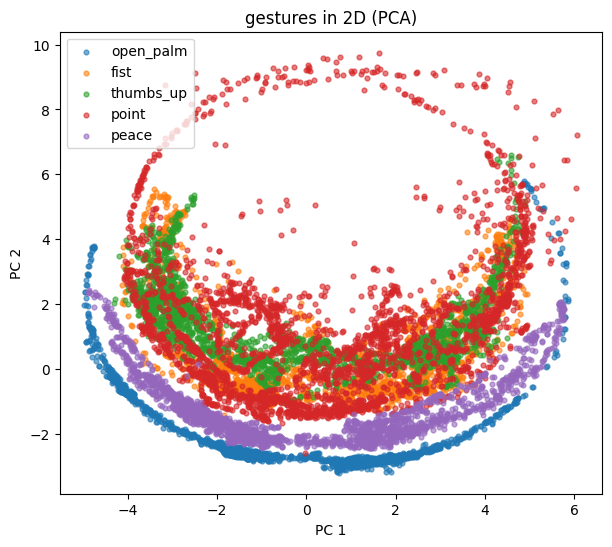

In [42]:
coords = PCA(n_components=2, random_state=42).fit_transform(X)
plt.figure(figsize=(7, 6))
for g in GESTURES:
    m = y == g
    plt.scatter(coords[m, 0], coords[m, 1], s=12, label=g, alpha=0.6)
plt.xlabel("PC 1"); plt.ylabel("PC 2"); plt.legend()
plt.title("gestures in 2D (PCA)"); plt.show()

Split off 20% for testing, keeping the classes balanced in both parts.

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print("train:", len(X_train), " test:", len(X_test))

train: 9856  test: 2464


Train a **Random Forest** (an ensemble of decision trees, like in the practice classes). It does not need the features scaled and gives feature importances for free.

In [44]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print("test accuracy:", round(accuracy_score(y_test, y_pred), 3))
print(classification_report(y_test, y_pred))

test accuracy: 1.0
              precision    recall  f1-score   support

        fist       1.00      1.00      1.00       450
   open_palm       1.00      1.00      1.00       476
       peace       1.00      1.00      1.00       482
       point       1.00      1.00      1.00       602
   thumbs_up       1.00      1.00      1.00       454

    accuracy                           1.00      2464
   macro avg       1.00      1.00      1.00      2464
weighted avg       1.00      1.00      1.00      2464



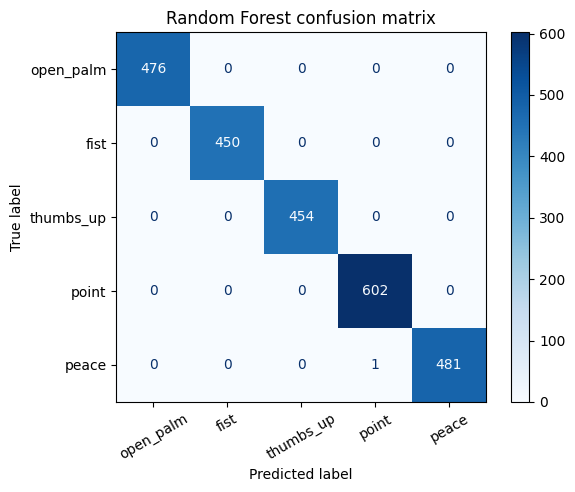

In [45]:
cm = confusion_matrix(y_test, y_pred, labels=GESTURES)
ConfusionMatrixDisplay(cm, display_labels=GESTURES).plot(cmap="Blues", xticks_rotation=30)
plt.title("Random Forest confusion matrix"); plt.show()

Almost everything is on the diagonal. The few mistakes are between `fist` and `thumbs_up`/`point`, which only differ by the thumb, so a half-curled thumb is genuinely ambiguous. `open_palm` is never confused.

To understand the model we vary the tree depth and watch the train vs test accuracy - the classic under/overfitting picture.

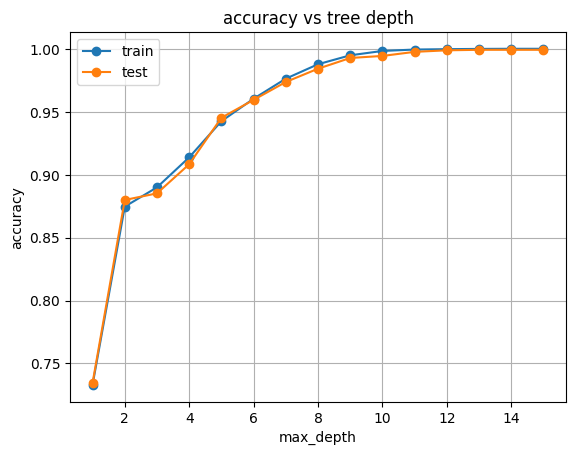

In [46]:
depths = range(1, 16)
train_acc, test_acc = [], []
for d in depths:
    m = RandomForestClassifier(n_estimators=200, max_depth=d, random_state=42).fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, m.predict(X_train)))
    test_acc.append(accuracy_score(y_test, m.predict(X_test)))
plt.plot(list(depths), train_acc, "o-", label="train")
plt.plot(list(depths), test_acc, "o-", label="test")
plt.xlabel("max_depth"); plt.ylabel("accuracy"); plt.legend(); plt.grid(True)
plt.title("accuracy vs tree depth"); plt.show()

Very shallow trees (depth 1-2) underfit. From about depth 7 the test accuracy flattens while the training accuracy keeps rising towards 1.0 - the trees start to memorise the training data. The forest averages many trees, so the test accuracy does not drop; a moderate depth is enough.

5-fold cross-validation is a more trustworthy score than a single split.

In [47]:
cv = cross_val_score(rf, X, y, cv=5)
print("folds:", np.round(cv, 3))
print("mean CV accuracy:", round(cv.mean(), 3), "+/-", round(cv.std(), 3))

folds: [0.938 0.911 0.96  0.984 0.898]
mean CV accuracy: 0.938 +/- 0.031


Which coordinates does the model rely on?

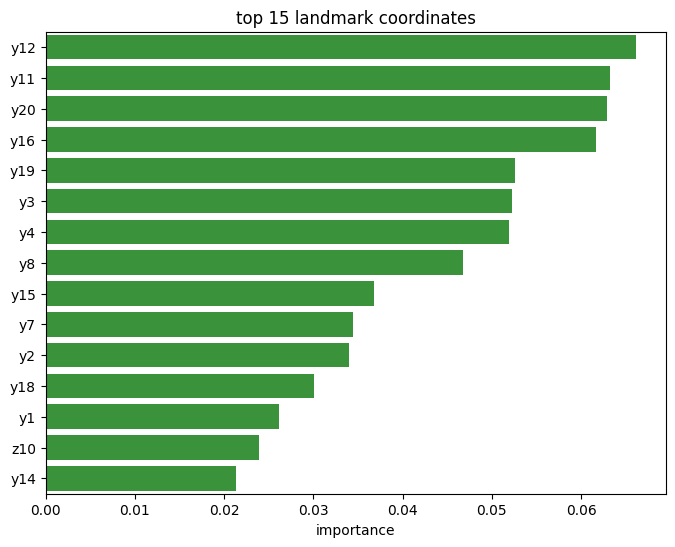

In [48]:
names = [f"{a}{i}" for i in range(21) for a in "xyz"]
imp = rf.feature_importances_
order = np.argsort(imp)[::-1][:15]
plt.figure(figsize=(8, 6))
sns.barplot(x=imp[order], y=np.array(names)[order], color="C2")
plt.title("top 15 landmark coordinates"); plt.xlabel("importance"); plt.show()

The most important coordinates belong to the **fingertips** (landmarks 4, 8, 12, 16, 20) - exactly the points that move when a finger is extended or curled.

Save the model so we can reuse it later.

In [49]:
best_model = rf
joblib.dump(best_model, "gesture_model.pkl")
print("saved gesture_model.pkl")

saved gesture_model.pkl


## 4. Comparing with an SVM

A **Support Vector Machine** looks for the widest gap between the classes.
Unlike the Random Forest it *is* sensitive to feature scale, so we put a
`StandardScaler` in front of it in a pipeline (fitted on the training folds
only, which avoids leakage) and tune `C` and `gamma` with a small grid search.

In [50]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV

pipe = make_pipeline(StandardScaler(), SVC(kernel="rbf", probability=True, random_state=42))
grid = GridSearchCV(pipe, {"svc__C": [1, 10, 100], "svc__gamma": ["scale", 0.01, 0.1]}, cv=5)
grid.fit(X_train, y_train)
svm = grid.best_estimator_
print("best params:", grid.best_params_)
print("SVM test accuracy:", round(accuracy_score(y_test, svm.predict(X_test)), 3))
print(classification_report(y_test, svm.predict(X_test)))

best params: {'svc__C': 100, 'svc__gamma': 'scale'}
SVM test accuracy: 1.0
              precision    recall  f1-score   support

        fist       1.00      1.00      1.00       450
   open_palm       1.00      1.00      1.00       476
       peace       1.00      1.00      1.00       482
       point       1.00      1.00      1.00       602
   thumbs_up       1.00      1.00      1.00       454

    accuracy                           1.00      2464
   macro avg       1.00      1.00      1.00      2464
weighted avg       1.00      1.00      1.00      2464



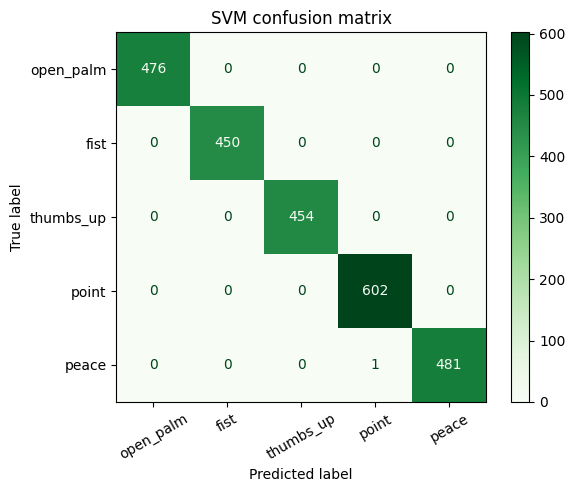

In [51]:
cm = confusion_matrix(y_test, svm.predict(X_test), labels=GESTURES)
ConfusionMatrixDisplay(cm, display_labels=GESTURES).plot(cmap="Greens", xticks_rotation=30)
plt.title("SVM confusion matrix"); plt.show()

The SVM makes the same kind of mistakes as the Random Forest. That two different algorithms struggle on the same gestures means the confusion comes from the data (similar hand shapes), not from one weak model. We keep whichever has the higher cross-validation score.

Random Forest CV: 0.938
SVM           CV: 0.943


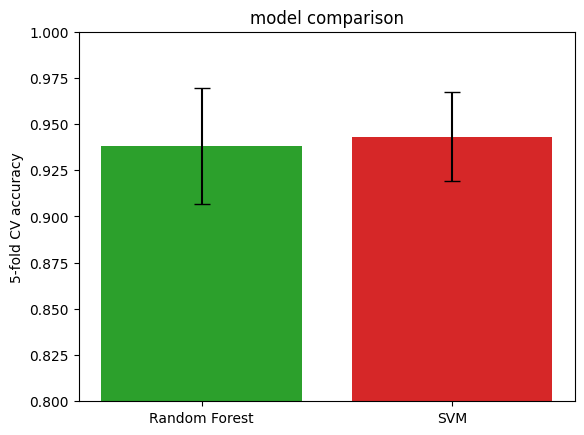

kept: SVM pipeline


In [52]:
cv_rf = cross_val_score(rf, X, y, cv=5)
cv_svm = cross_val_score(svm, X, y, cv=5)
print("Random Forest CV:", round(cv_rf.mean(), 3))
print("SVM           CV:", round(cv_svm.mean(), 3))

plt.bar(["Random Forest", "SVM"], [cv_rf.mean(), cv_svm.mean()],
        yerr=[cv_rf.std(), cv_svm.std()], capsize=6, color=["C2", "C3"])
plt.ylim(0.8, 1.0); plt.ylabel("5-fold CV accuracy"); plt.title("model comparison"); plt.show()

best_model = rf if cv_rf.mean() >= cv_svm.mean() else svm
joblib.dump(best_model, "gesture_model.pkl")
print("kept:", type(best_model).__name__ if not hasattr(best_model, "steps") else "SVM pipeline")

## The live demo

Finally we map each gesture to a simulated robot command and run it live. To
stop the command from flickering, it is only issued once the same gesture has
been seen for a few frames and the model is confident. Run `run_live_control()`
(after running the cells above) and press **q** to quit.

In [53]:
from collections import deque

COMMANDS = {"open_palm": "STOP", "fist": "GRAB", "thumbs_up": "MOVE FORWARD",
            "point": "TURN", "peace": "SPEED UP"}


def run_live_control():
    """Live webcam demo: gesture -> robot command (press q to quit)."""
    detector = create_landmarker("video")
    cap = cv2.VideoCapture(0)
    recent, command = deque(maxlen=5), "---"
    start, last = time.perf_counter(), -1
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        frame = cv2.flip(frame, 1)
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        ts = max(last + 1, int((time.perf_counter() - start) * 1000)); last = ts
        result = detector.detect_for_video(mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb), ts)
        draw_landmarks(frame, result.hand_landmarks)
        gesture, conf = "none", 0.0
        if result.hand_landmarks:
            feat = normalize_landmarks(landmarks_to_array(result.hand_landmarks[0])).reshape(1, -1)
            gesture = best_model.predict(feat)[0]
            conf = float(best_model.predict_proba(feat).max())
            recent.append(gesture if conf >= 0.6 else "none")
            if len(recent) == 5 and len(set(recent)) == 1:
                command = COMMANDS.get(recent[0], "---")
        cv2.putText(frame, f"{gesture} ({conf:.2f})", (10, 35),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)
        cv2.putText(frame, f"COMMAND: {command}", (10, 75),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 128, 255), 3)
        cv2.imshow("gesture control (press q)", frame)
        if cv2.waitKey(1) & 0xFF == ord("q"):
            break
    cap.release(); cv2.destroyAllWindows(); detector.close()

In [55]:
run_live_control()

## Conclusion

**Summary.** Both a Random Forest and an SVM recognise the five gestures with about 94% accuracy. The fingertip coordinates are the most important features. The chosen model drives `run_live_control()`, turning a live hand gesture into a robot command.